In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from utils.utils_read import load_results, _sanitize_answer
from utils.utils_graph import make_balanced_matrix


BASE_PATH = Path(
    "/data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/"
)

# Map label -> run_name (folder under BASE_PATH).
RUNS = {
    "run_25_roi_ablation_baseline": "run_25_roi_ablation_baseline",
    # "run_25_roi_circling_no_text": "run_25_roi_circling_no_text",
    # "run_25_roi_circling_no_text_layout_position": "run_25_roi_circling_no_text_layout_position",         
}

# If non-empty, compute metrics per model_id in this list.
MODELS: list[str] = []


def _build_eval_df(base_path: Path, run_name: str) -> pd.DataFrame | None:
    run_folder = Path(run_name)
    results_dir = base_path / run_folder / f"results_{run_folder}_sanitized"
    model_cols = sorted(p.stem.replace("_val", "") for p in results_dir.glob("*_val.json"))
    if not model_cols:
        print(f"Skipping {run_name}: no model results in {results_dir}")
        return None

    df = load_results(
        base_path,
        run_folder,
        merge_model_answers=True,
        model_answers_wide=True,
        cache=True,
    )

    model_cols = [c for c in model_cols if c in df.columns]
    if not model_cols:
        print(f"Skipping {run_name}: no matching model columns in data")
        return None

    df["answer"] = df["answer"].apply(
        lambda a: _sanitize_answer(a, max_prefix_chars=None)
    )

    id_cols = [
        c
        for c in [
            "idx",
            "question_id",
            "category",
            "sub_category",
            "num_objects",
            "object_count",
            "answer",
            "mode_test",
            "mode_val",
            "mode",
        ]
        if c in df.columns
    ]

    eval_df = df.melt(
        id_vars=id_cols,
        value_vars=model_cols,
        var_name="model_id",
        value_name="model_answer",
    )

    valid = eval_df["model_answer"].notna() & eval_df["answer"].notna()
    eval_df["is_correct"] = pd.NA
    eval_df.loc[valid, "is_correct"] = (
        eval_df.loc[valid, "model_answer"] == eval_df.loc[valid, "answer"]
    )

    return eval_df


In [2]:
base_path = BASE_PATH
run_name = RUNS["run_25_roi_ablation_baseline"]

eval_df = _build_eval_df(base_path, run_name)

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl


In [3]:
eval_df

,idx,question_id,category,sub_category,answer,mode_test,mode_val,model_id,model_answer,is_correct
0,3483_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,A,image-only,image-only,Aquila-VL-2B,B,False
1,5545_i,F_MASS_OBJECT,material_understanding,mass,B,image-only,image-only,Aquila-VL-2B,C,False
2,727_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,C,image-only,image-only,Aquila-VL-2B,B,False
3,5099_g,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,A,general,general,Aquila-VL-2B,NaN,<NA>
4,3096_i,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,C,image-only,image-only,Aquila-VL-2B,A,False
...,...,...,...,...,...,...,...,...,...,...
45811,3154_g,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_1,material_understanding,material_identification,D,general,general,vila-1.5-8b,A,False
45812,272_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,A,general,general,vila-1.5-8b,A,True
45813,3586_i,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_3,material_understanding,material_identification,B,image-only,image-only,vila-1.5-8b,A,False
45814,3609_i,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,A,image-only,image-only,vila-1.5-8b,A,True


In [13]:
df_young_modulus = eval_df[
    (eval_df["sub_category"] == "young_modulus") &
    (eval_df["model_id"] == "Aquila-VL-2B")
]

In [14]:
df_young_modulus = eval_df[
    (eval_df["sub_category"] == "young_modulus") &
    (eval_df["model_id"] == "Aquila-VL-2B")
]

df_young_modulus_correct = df_young_modulus['is_correct'].value_counts()
print(df_young_modulus_correct)
print(df_young_modulus_correct[True] / df_young_modulus_correct.sum())

is_correct
False    67
True     39
Name: count, dtype: int64
0.36792452830188677


In [10]:
df_mass = eval_df[eval_df["sub_category"] == "mass"]
df_mass_correct = df_mass['is_correct'].value_counts()
print(df_mass_correct)
print(df_mass_correct[True] / df_mass_correct.sum())

is_correct
False    5455
True     1699
Name: count, dtype: int64
0.237489516354487


In [15]:
for sub_cat in eval_df["sub_category"].unique():
    df_sub = eval_df[eval_df["sub_category"] == sub_cat]
    df_sub_correct = df_sub['is_correct'].value_counts()
    acc = df_sub_correct[True] / df_sub_correct.sum()
    print(f"Sub-category: {sub_cat}, Accuracy: {acc:.4f}")

Sub-category: young_modulus, Accuracy: 0.2513
Sub-category: mass, Accuracy: 0.2375
Sub-category: density, Accuracy: 0.1099
Sub-category: poisson_ratio, Accuracy: 0.2812
Sub-category: material_identification, Accuracy: 0.4583


In [ ]:

runs = [
    "run_25_roi_ablation_baseline",
]

for run_name in runs:

    eval_df = _build_eval_df(base_path, run_name)

    total_accuracy_per_run = 0.0

    for model_id in eval_df["model_id"].unique():
        # print(f"Metrics for model: {model_id}")
        total_accuracy_per_model = 0.0

        for sub_cat in eval_df["sub_category"].unique():
            df_sub_category_model = eval_df[
                (eval_df["sub_category"] == sub_cat) &
                (eval_df["model_id"] == model_id)
            ]
            df_sub_correct = df_sub_category_model['is_correct'].value_counts()
            acc = df_sub_correct[True] / df_sub_correct.sum()
            print(f"Sub-category: {sub_cat}, Accuracy: {acc:.4f}")
            total_accuracy_per_run += acc              
        
        total_accuracy_per_model /= len(eval_df["sub_category"].unique())

        total_accuracy_per_run += total_accuracy_per_model        
        print(f"Overall Macro Accuracy for model {model_id}: ", end="")
        print(f"{total_accuracy_per_model:.4f}")

    total_accuracy_per_run /= len(eval_df["model_id"].unique())
    print(f"Overall Macro Accuracy for run {run_name}: ", end="")
    print(f"{total_accuracy_per_run:.4f}")

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Sub-category: young_modulus, Accuracy: 0.3679
Sub-category: mass, Accuracy: 0.3645
Sub-category: density, Accuracy: 0.0577
Sub-category: poisson_ratio, Accuracy: 0.4615
Sub-category: material_identification, Accuracy: 0.4815
Overall Macro Accuracy for model Aquila-VL-2B: 0.0000
Sub-category: young_modulus, Accuracy: 0.2830
Sub-category: mass, Accuracy: 0.1215
Sub-category: density, Accuracy: 0.1058
Sub-category: poisson_ratio, Accuracy: 0.0288
Sub-category: material_identification, Accuracy: 0.4444
Overall Macro Accuracy for model InternVL-Chat-V1-5-quantable: 0.0000
Sub-category: young_modulus, Accuracy: 0.2071
Sub-category: mass, Accuracy: 0.2900
Sub-category: density, Accuracy: 0.0700
Sub-category: poisson_ratio, Accuracy: 0.6378
Sub-category: material_identification, Accuracy: 0.4406
Overall Macro Accuracy for model InternVL2-1B: 0.0000
Sub-category

In [30]:

runs = [
    "run_25_roi_ablation_baseline",
]

for run_name in runs:

    eval_df = _build_eval_df(base_path, run_name)

    total_accuracy_per_run = 0.0

    for model_id in eval_df["model_id"].unique():
        total_accuracy_per_model = 0.0

        for sub_cat in eval_df["sub_category"].unique():
            df_sub_category_model = eval_df[
                (eval_df["sub_category"] == sub_cat) &
                (eval_df["model_id"] == model_id)
            ]
            df_sub_correct = df_sub_category_model['is_correct'].value_counts()
            acc = df_sub_correct[True] / df_sub_correct.sum()
            print(f"Sub-category: {sub_cat}, Accuracy: {acc:.4f}")
            total_accuracy_per_model += acc              
        
        total_accuracy_per_model /= len(eval_df["sub_category"].unique())
            
        print(f"Overall Macro Accuracy for model {model_id}: ", end="")
        print(f"{total_accuracy_per_model:.4f}")

        total_accuracy_per_run += total_accuracy_per_model

    total_accuracy_per_run /= len(eval_df["model_id"].unique())
    print(f"Overall Macro Accuracy for run {run_name}: ", end="")
    print(f"{total_accuracy_per_run:.4f}")

Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Sub-category: young_modulus, Accuracy: 0.3679
Sub-category: mass, Accuracy: 0.3645
Sub-category: density, Accuracy: 0.0577
Sub-category: poisson_ratio, Accuracy: 0.4615
Sub-category: material_identification, Accuracy: 0.4815
Overall Macro Accuracy for model Aquila-VL-2B: 0.3466
Sub-category: young_modulus, Accuracy: 0.2830
Sub-category: mass, Accuracy: 0.1215
Sub-category: density, Accuracy: 0.1058
Sub-category: poisson_ratio, Accuracy: 0.0288
Sub-category: material_identification, Accuracy: 0.4444
Overall Macro Accuracy for model InternVL-Chat-V1-5-quantable: 0.1967
Sub-category: young_modulus, Accuracy: 0.2071
Sub-category: mass, Accuracy: 0.2900
Sub-category: density, Accuracy: 0.0700
Sub-category: poisson_ratio, Accuracy: 0.6378
Sub-category: material_identification, Accuracy: 0.4406
Overall Macro Accuracy for model InternVL2-1B: 0.3291
Sub-category

In [33]:
import pandas as pd

run_acc = []

runs = [
    "run_25_roi_ablation_baseline",
    "run_25_roi_circling_no_text",
    "run_25_roi_circling_no_text_layout_position",
    "run_25_roi_circling_text",
    "run_25_roi_circling_text_layout_position",
]

for run_name in runs:
    eval_df = _build_eval_df(base_path, run_name)

    model_macro = []

    for model_id in eval_df["model_id"].unique():
        sub_acc = []

        for sub_cat in eval_df["sub_category"].unique():
            df = eval_df[
                (eval_df["sub_category"] == sub_cat) &
                (eval_df["model_id"] == model_id)
            ]
            vc = df["is_correct"].value_counts()
            acc = vc.get(True, 0) / vc.sum()
            sub_acc.append(acc)

        model_macro.append(sum(sub_acc) / len(sub_acc))

    run_acc.append({
        "run": run_name,
        "macro_accuracy": sum(model_macro) / len(model_macro)
    })

plot_df = pd.DataFrame(run_acc)


Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text_layout_position/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_text/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_text_layout_position/merged_results.pkl


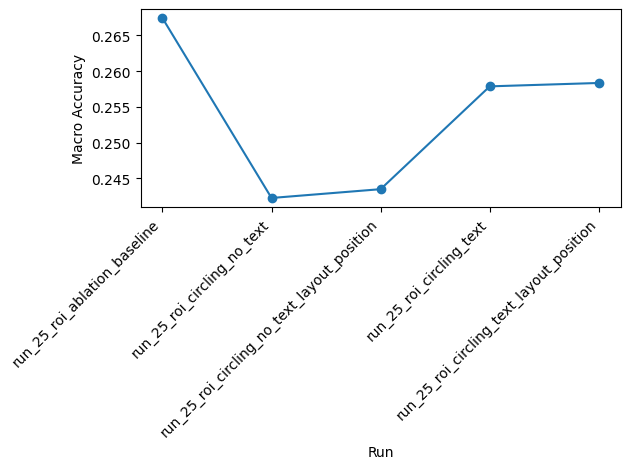

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(plot_df["run"], plot_df["macro_accuracy"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro Accuracy")
plt.xlabel("Run")
plt.tight_layout()
plt.show()

In [35]:
rows = []

for run_name in runs:
    eval_df = _build_eval_df(base_path, run_name)

    for model_id in eval_df["model_id"].unique():
        sub_acc = []

        for sub_cat in eval_df["sub_category"].unique():
            df = eval_df[
                (eval_df["sub_category"] == sub_cat) &
                (eval_df["model_id"] == model_id)
            ]
            vc = df["is_correct"].value_counts()
            acc = vc.get(True, 0) / vc.sum()
            sub_acc.append(acc)

        rows.append({
            "run": run_name,
            "model": model_id,
            "macro_accuracy": sum(sub_acc) / len(sub_acc)
        })

plot_df = pd.DataFrame(rows)


Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_no_text_layout_position/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_text/merged_results.pkl
Cache found at  /data0/sebastian.cavada/compositional-physics/tiny_vqa_creation/output/run_25_roi_circling_text_layout_position/merged_results.pkl


/tmp/ipykernel_1256437/2183868665.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


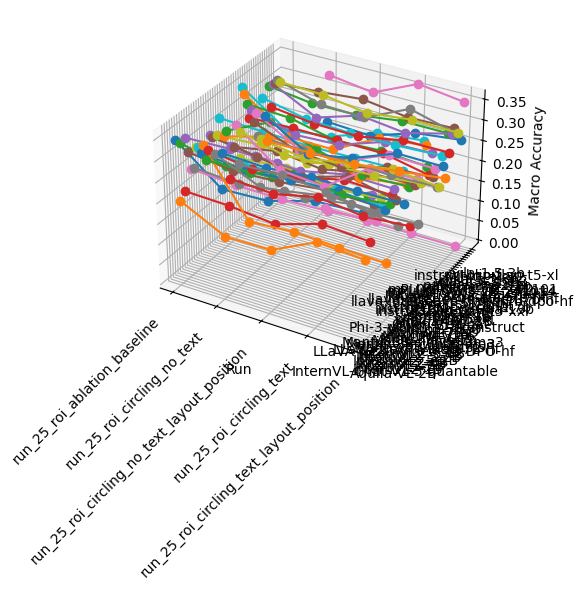

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

run_ids = {r: i for i, r in enumerate(plot_df["run"].unique())}
model_ids = {m: i for i, m in enumerate(plot_df["model"].unique())}

for model, df_m in plot_df.groupby("model"):
    x = df_m["run"].map(run_ids)          # run axis
    y = [model_ids[model]] * len(df_m)    # model axis (constant line)
    z = df_m["macro_accuracy"]             # accuracy
    ax.plot(x, y, z, marker="o")

ax.set_xlabel("Run")
ax.set_ylabel("Model")
ax.set_zlabel("Macro Accuracy")
ax.set_xticks(list(run_ids.values()))
ax.set_xticklabels(run_ids.keys(), rotation=45, ha="right")
ax.set_yticks(list(model_ids.values()))
ax.set_yticklabels(model_ids.keys())

plt.tight_layout()
plt.show()


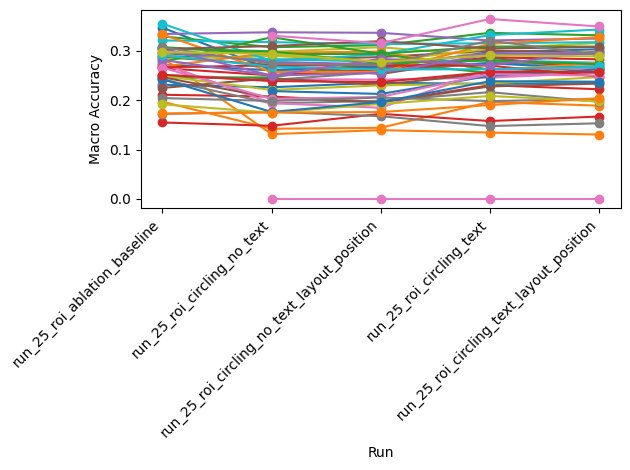

In [38]:
import matplotlib.pyplot as plt

plt.figure()

for model, df_m in plot_df.groupby("model"):
    plt.plot(
        df_m["run"],
        df_m["macro_accuracy"],
        marker="o",
        label=model
    )

plt.xlabel("Run")
plt.ylabel("Macro Accuracy")
plt.xticks(rotation=45, ha="right")
# plt.legend()
plt.tight_layout()
plt.show()


In [39]:
len(eval_df["model_id"].unique())

48

In [40]:
eval_df

,idx,question_id,category,sub_category,answer,mode_test,mode_val,model_id,model_answer,is_correct
0,3483_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,A,image-only,image-only,Aquila-VL-2B,B,False
1,5545_i,F_MASS_OBJECT,material_understanding,mass,B,image-only,image-only,Aquila-VL-2B,C,False
2,727_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,C,image-only,image-only,Aquila-VL-2B,B,False
3,5099_g,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,A,general,general,Aquila-VL-2B,NaN,<NA>
4,3096_i,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,C,image-only,image-only,Aquila-VL-2B,A,False
...,...,...,...,...,...,...,...,...,...,...
47803,3154_g,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_1,material_understanding,material_identification,D,general,general,vila-1.5-8b,A,False
47804,272_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,A,general,general,vila-1.5-8b,A,True
47805,3586_i,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_3,material_understanding,material_identification,B,image-only,image-only,vila-1.5-8b,A,False
47806,3609_i,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,A,image-only,image-only,vila-1.5-8b,A,True


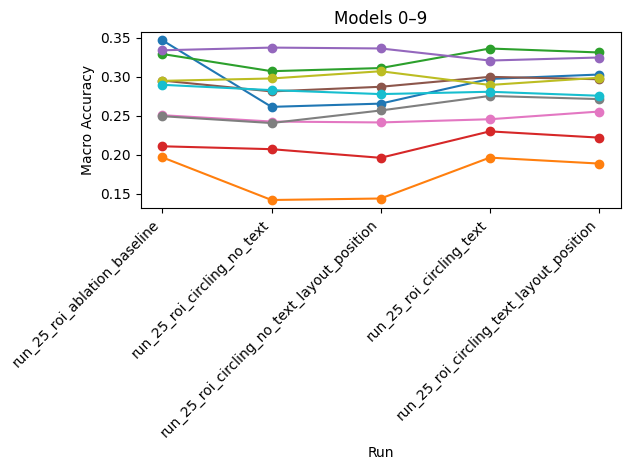

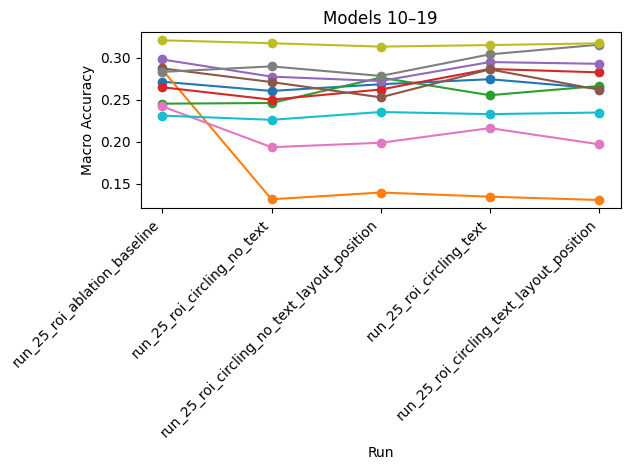

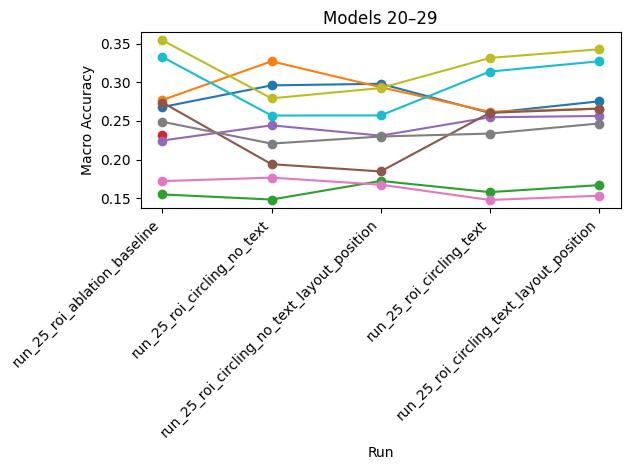

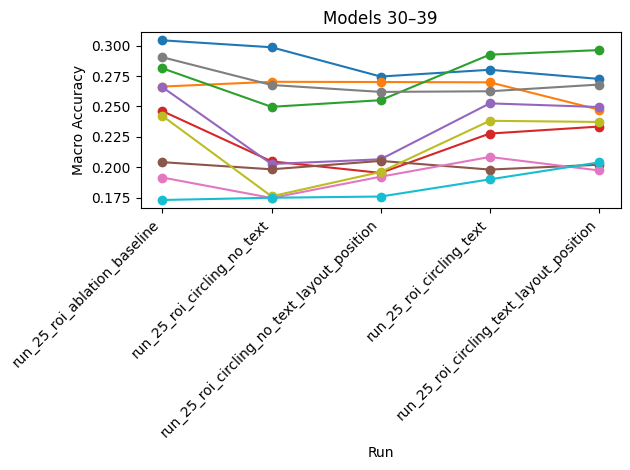

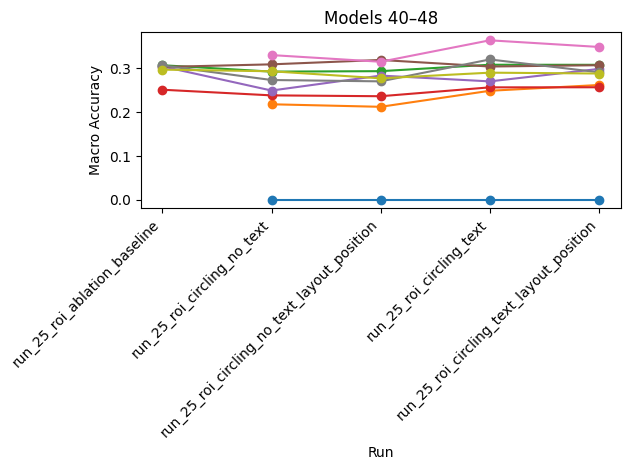

In [47]:
import matplotlib.pyplot as plt
import math

models = list(plot_df["model"].unique())
runs = list(plot_df["run"].unique())

models_per_fig = 10
n_figs = math.ceil(len(models) / models_per_fig)

for i in range(n_figs):
    model_chunk = models[i * models_per_fig:(i + 1) * models_per_fig]
    df_chunk = plot_df[plot_df["model"].isin(model_chunk)]

    plt.figure()

    for model, df_m in df_chunk.groupby("model"):
        df_m = (
        df_m.set_index("run")
            .reindex(runs)        # missing runs → NaN
            .reset_index()
       )
        plt.plot(df_m["run"], df_m["macro_accuracy"], marker="o", label=model)

    plt.xlabel("Run")
    plt.ylabel("Macro Accuracy")
    plt.title(f"Models {i*models_per_fig}–{min((i+1)*models_per_fig, len(models))-1}")
    plt.xticks(rotation=45, ha="right")
    # plt.legend()
    plt.tight_layout()
    plt.show()


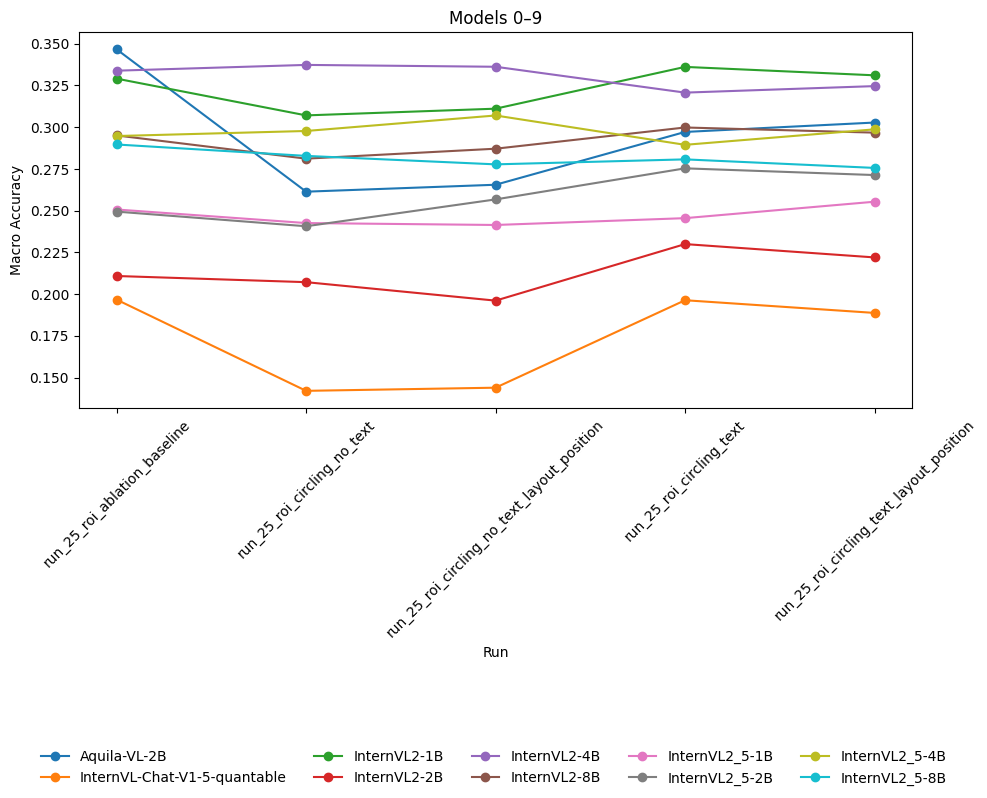

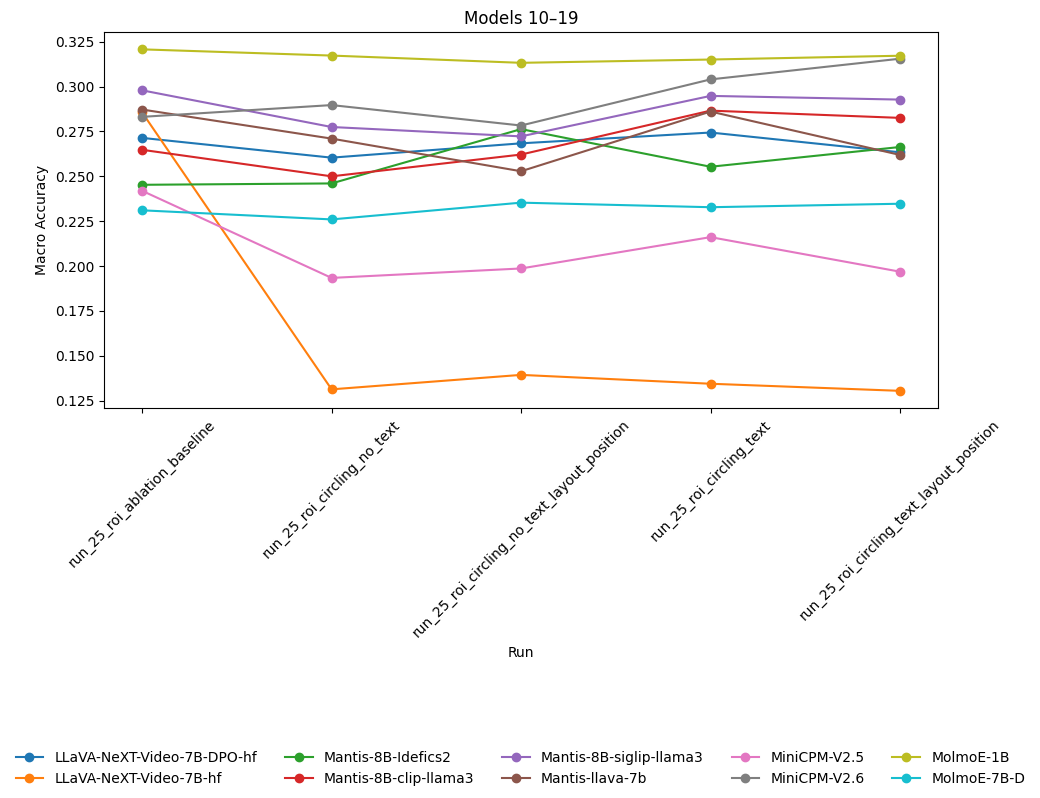

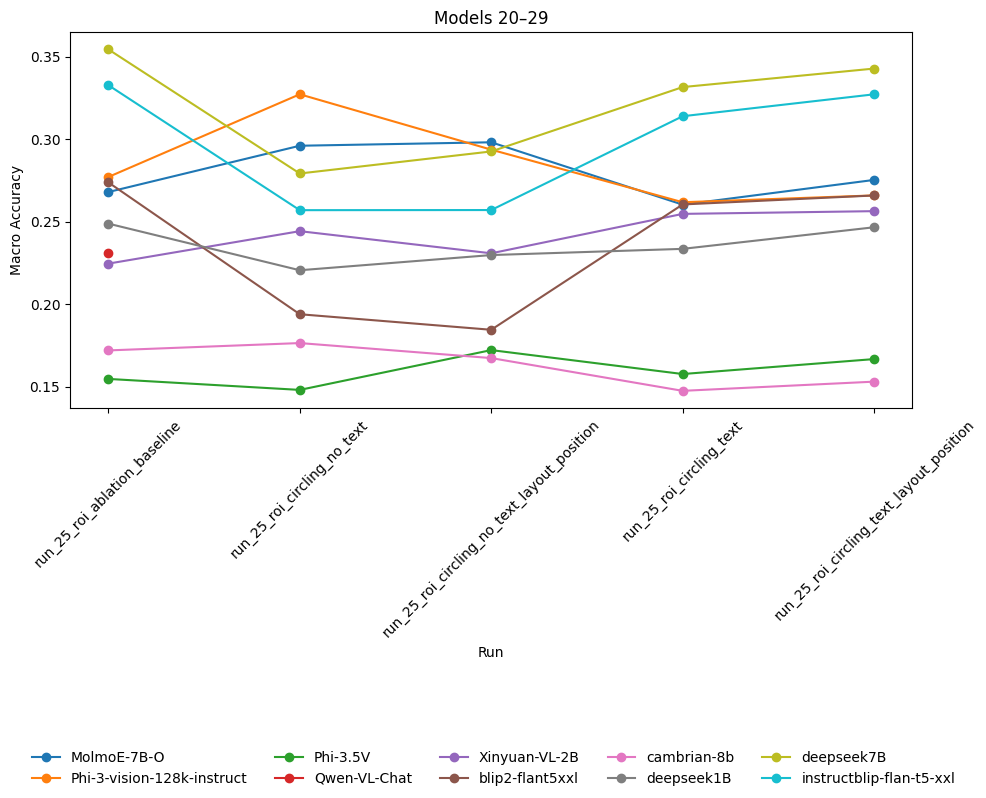

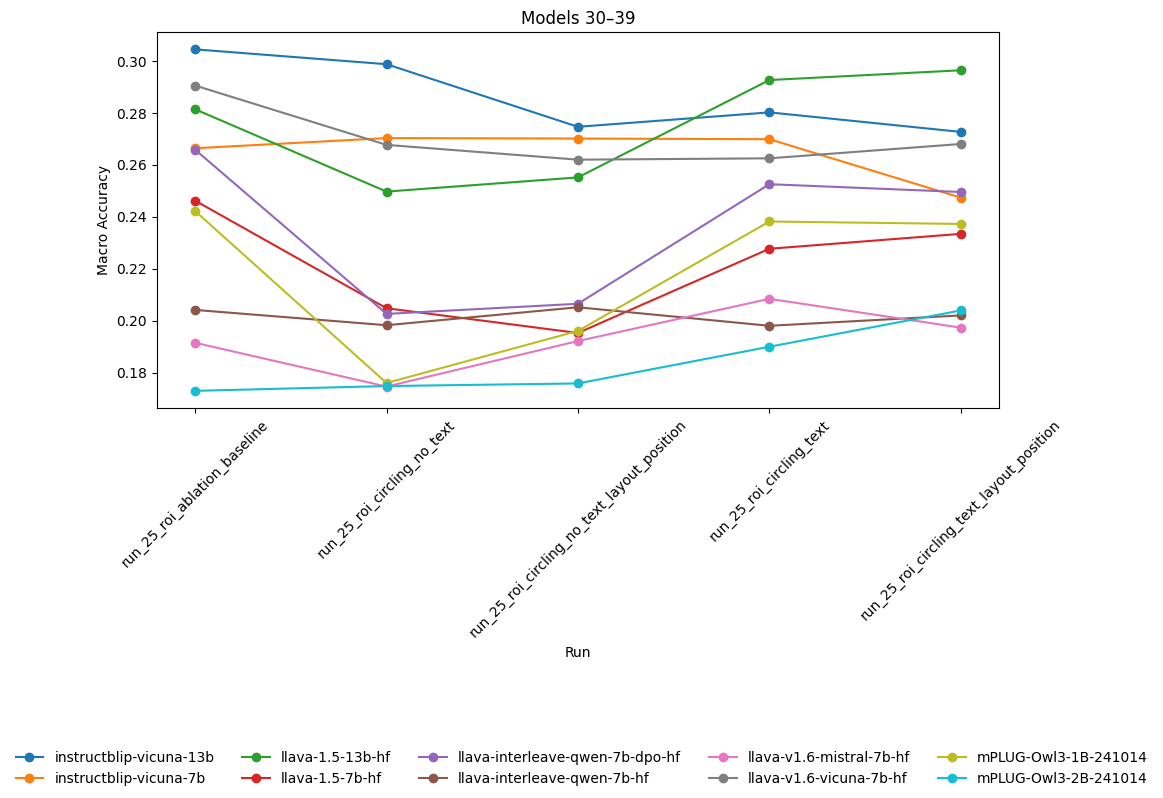

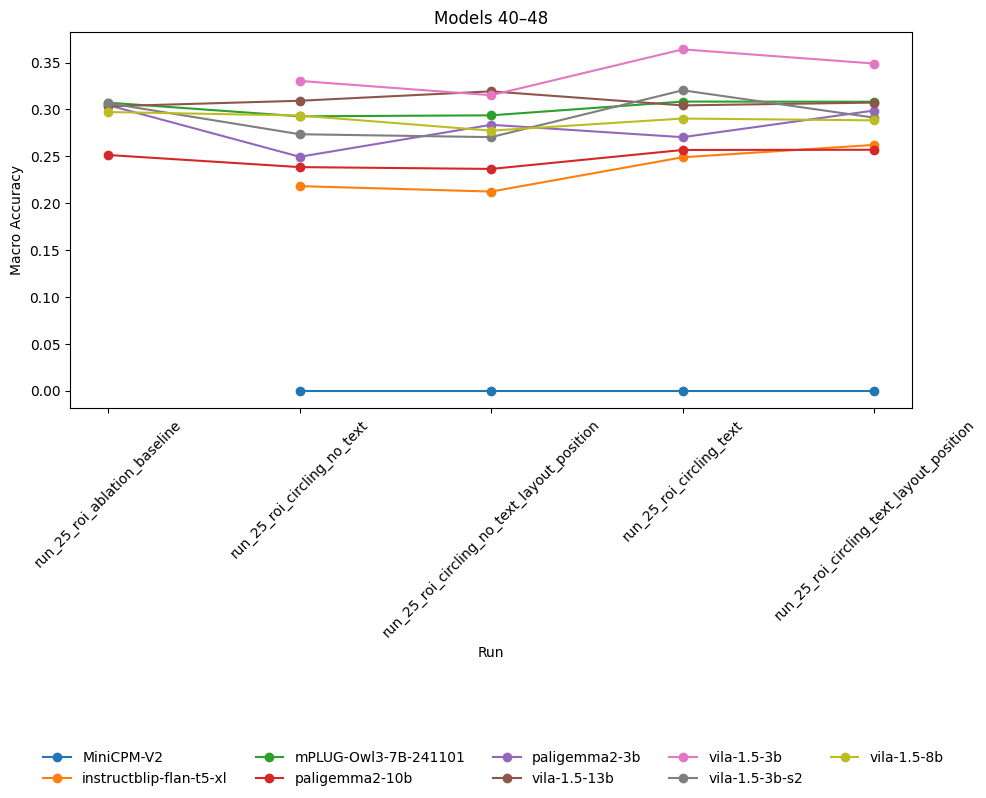

In [50]:
import matplotlib.pyplot as plt
import math

models = list(plot_df["model"].unique())
runs = list(plot_df["run"].unique())

models_per_fig = 10
n_figs = math.ceil(len(models) / models_per_fig)

for i in range(n_figs):
    model_chunk = models[i*models_per_fig:(i+1)*models_per_fig]
    df_chunk = plot_df[plot_df["model"].isin(model_chunk)]

    fig, ax = plt.subplots(figsize=(10, 8))

    handles = []
    labels = []

    for model, df_m in df_chunk.groupby("model"):
        df_m = (
            df_m.set_index("run")
                .reindex(runs)
                .reset_index()
        )
        line, = ax.plot(
            df_m["run"],
            df_m["macro_accuracy"],
            marker="o",
            label=model
        )
        handles.append(line)
        labels.append(model)

    ax.set_xlabel("Run")
    ax.set_ylabel("Macro Accuracy")
    ax.set_title(f"Models {i*models_per_fig}–{min((i+1)*models_per_fig, len(models))-1}")
    ax.tick_params(axis="x", rotation=45)    

    # 🔑 single legend for the whole figure
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=5,
        frameon=False
    )

    fig.tight_layout(rect=[0, 0.15, 1, 1])  # leave space for legend
    plt.show()
